# Battery Report

Analysis of one or more CarbonShift solver battery runs. Pick which run
folder(s) under `results/` to analyse in the cell below (auto-detected from
`battery_results_*.csv` files); no manual path editing needed.

In [37]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams["figure.dpi"] = 96
plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Mode filter: which infeasibility modes to include in plots ───────────────
#   "greedy_fallback" | "relaxed_retry" | "both"
SHOW_MODES: str = "both"

# ── Visual styles for strategies ────────────────────────────────────────────
# Keys use the full infeasibility_mode value as it appears in the CSV.
#   "offline_*" : single-pass swarm offline (no N dimension) — new-style naming
#   bare names  : same, backward-compat with old CSVs without "offline_" prefix
#   "online_*"  : scheduler-pipeline online (per-N lines)
STRATEGY_STYLE: dict = {
    "offline_greedy_cheapest": {"color": "tab:green",  "marker": "D",  "linestyle": "none"},
    "offline_bandit":          {"color": "tab:purple", "marker": "^",  "linestyle": "none"},
    "offline_ant_colony":      {"color": "tab:cyan",   "marker": "*",  "linestyle": "none"},
    # backward-compat bare names (old CSVs)
    "greedy_cheapest":         {"color": "tab:green",  "marker": "D",  "linestyle": "none"},
    "bandit":                  {"color": "tab:purple", "marker": "^",  "linestyle": "none"},
    "ant_colony":              {"color": "tab:cyan",   "marker": "*",  "linestyle": "none"},
}
ONLINE_STRATEGY_STYLE: dict = {
    "online_bandit":     {"color": "tab:purple", "linestyle": "--", "marker": "^"},
    "online_ant_colony": {"color": "tab:cyan",   "linestyle": "--", "marker": "*"},
}
_STRATEGY_FALLBACK_COLORS = ["tab:brown", "tab:pink", "tab:olive"]


# ── Metrics to plot ───────────────────────────────────────────────────────────
METRICS: list[dict] = [
    {"col": "solver_time_ms_avg",              "label": "Solver time (ms avg)"},
    {"col": "total_carbon_cost",               "label": "Total carbon cost"},
    {"col": "final_global_error",              "label": "Final global error"},
    {"col": "avg_global_error_per_slot",       "label": "Avg global error / slot"},
    {"col": "carbon_cost_saving_vs_baseline_pct", "label": "Carbon saving vs baseline (%)"},
    {"col": "total_rollbacks",                 "label": "Total rollbacks (Rust only)"},
    {"col": "max_consecutive_rollbacks",       "label": "Max consecutive rollbacks"},
    {"col": "peak_concurrent_workers",         "label": "Peak concurrent workers"},
    {"col": "avg_concurrent_workers",          "label": "Avg concurrent workers"},
]

MODE_STYLE: dict = {
    "greedy_fallback": {"linestyle": "-",  "marker": "o"},
    "relaxed_retry":   {"linestyle": "--", "marker": "s"},
}

BACKEND_COLOR: dict = {
    "python": {"greedy_fallback": "tab:blue",   "relaxed_retry": "tab:cyan"},
    "rust":   {"greedy_fallback": "tab:orange", "relaxed_retry": "tab:red"},
}


In [38]:
# ── Pick which battery run(s) to analyse ──────────────────────────────────
# Auto-discovers every folder under `results/` that directly contains
# `battery_results_*.csv` file(s) — both the new per-run folders written by
# run_battery.py (e.g. results/<battery_id>_<mmdd>_<hhmm>_.../) and the
# legacy flat layout (CSVs straight under results/) are supported.

_nb_dir = Path(__file__) if "__file__" in dir() else Path.cwd()
RESULTS_ROOT = _nb_dir / "results"

def _find_run_dirs(root: Path) -> list[Path]:
    """Dirs directly containing battery_results_*.csv, most recent first."""
    dirs = {p.parent for p in root.glob("**/battery_results_*.csv")}
    # filter out dir named "archive" and all subdirs under it, since those are not active runs
    dirs = [d for d in dirs if "archive" not in d.parts]
    return sorted(
        dirs,
        key=lambda d: max((f.stat().st_mtime for f in d.glob("battery_results_*.csv")), default=0),
        reverse=True,
    )

_available_runs = _find_run_dirs(RESULTS_ROOT)
print(f"Found {len(_available_runs)} run folder(s) under {RESULTS_ROOT}:")
for i, d in enumerate(_available_runs):
    rel = d.relative_to(RESULTS_ROOT) if d != RESULTS_ROOT else Path(".")
    csvs = sorted(f.name for f in d.glob("battery_results_*.csv"))
    print(f"  [{i}] {rel}  ({', '.join(csvs)})")

# Indices (from the list above) of the run(s) to load. Defaults to the single
# most recent run. To compare multiple runs side by side, e.g. [0, 2].
SELECTED_RUNS: list[int] = [0]

RESULT_CSVS: list[Path] = [
    f for i in SELECTED_RUNS for f in sorted(_available_runs[i].glob("battery_results_*.csv"))
]
print(f"\nAnalysing: {[str(p.relative_to(RESULTS_ROOT)) for p in RESULT_CSVS]}")


Found 3 run folder(s) under /home/francis/unipi/carbonshift/carbonshift/tests/battery/results:
  [0] low2xx_cf0716_0711_1443_1_0_T  (battery_results_low2xx_cf0716.csv)
  [1] low2xx_cf0716_0709_1436_8_0_T  (battery_results_low2xx_cf0716.csv)
  [2] low2xx_cf0716_0709_1359_20_0_T  (battery_results_low2xx_cf0716.csv)

Analysing: ['low2xx_cf0716_0711_1443_1_0_T/battery_results_low2xx_cf0716.csv']


In [39]:
frames = []
for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p
    if not p.is_absolute():
        p = (_nb_dir / p).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Results CSV not found: {p}")
    _df = pd.read_csv(p)
    stem = p.stem
    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"
    _df.insert(0, "battery_id", bid)
    frames.append(_df)

df = pd.concat(frames, ignore_index=True)
df["batch_size"] = df["batch_size"].astype(int)
# Drop rows that are exact duplicates on the natural key (produced by old buggy builds).
df = df.drop_duplicates(
    subset=["scenario_id", "backend", "infeasibility_mode", "batch_size"], keep="first"
)

for _rb_col in ("total_rollbacks", "max_consecutive_rollbacks",
                "peak_concurrent_workers", "avg_concurrent_workers"):
    if _rb_col not in df.columns:
        df[_rb_col] = 0
df["total_rollbacks"] = df["total_rollbacks"].fillna(0).astype(int)
df["max_consecutive_rollbacks"] = df["max_consecutive_rollbacks"].fillna(0).astype(int)

# ── Classify infeasibility modes ─────────────────────────────────────────────
# DP scheduling modes (the baseline comparison lines):
_KNOWN_MODES = {"greedy_fallback", "relaxed_retry"}
_all_other_modes = set(df["infeasibility_mode"].unique()) - _KNOWN_MODES

# Online strategies: scheduler pipeline, per-N results (prefix "online_").
ONLINE_STRATEGY_NAMES: list[str] = sorted(
    s for s in _all_other_modes if s.startswith("online_")
)
# Offline strategies: single-pass swarm, no N dimension (prefix "offline_" or bare name
# for backward-compat with old CSVs that don't have the prefix).
STRATEGY_NAMES: list[str] = sorted(_all_other_modes - set(ONLINE_STRATEGY_NAMES))

df_modes  = df[df["infeasibility_mode"].isin(_KNOWN_MODES)].copy()
df_strat  = df[df["infeasibility_mode"].isin(STRATEGY_NAMES)].copy()
df_online = df[df["infeasibility_mode"].isin(ONLINE_STRATEGY_NAMES)].copy()

# Apply SHOW_MODES filter
if SHOW_MODES == "greedy_fallback":
    df_modes = df_modes[df_modes["infeasibility_mode"] == "greedy_fallback"].copy()
elif SHOW_MODES == "relaxed_retry":
    df_modes = df_modes[df_modes["infeasibility_mode"] == "relaxed_retry"].copy()

scenarios   = sorted(df["scenario_id"].unique())
# Include N values from online strategies so bs_to_x covers them too.
_online_batch_sizes = set(df_online["batch_size"].unique()) if not df_online.empty else set()
batch_sizes = sorted(set(df_modes["batch_size"].unique()) | _online_batch_sizes)
combos = sorted(
    df_modes[["backend", "infeasibility_mode"]].drop_duplicates().itertuples(index=False, name=None)
)

def _xaxis_info():
    """Build categorical x-axis covering batch sizes then strategies."""
    labels     = [f"N={n}" for n in batch_sizes] + STRATEGY_NAMES
    bs_to_x    = {n: i for i, n in enumerate(batch_sizes)}
    strat_to_x = {s: len(batch_sizes) + i for i, s in enumerate(STRATEGY_NAMES)}
    return labels, bs_to_x, strat_to_x, len(batch_sizes)

x_labels, bs_to_x, strat_to_x, n_bs = _xaxis_info()

print(
    f"Loaded {len(df)} rows · batteries={sorted(df['battery_id'].unique())} · "
    f"scenarios={len(scenarios)} · backends={sorted(df['backend'].unique())} · "
    f"N={batch_sizes} · modes={sorted(df_modes['infeasibility_mode'].unique())} "
    f"(SHOW_MODES={SHOW_MODES!r}) · offline={STRATEGY_NAMES} · online={ONLINE_STRATEGY_NAMES}"
)

df


Loaded 240 rows · batteries=['low2xx_cf0716'] · scenarios=10 · backends=['rust'] · N=[np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(16)] · modes=['relaxed_retry'] (SHOW_MODES='both') · offline=['offline_ant_colony', 'offline_bandit', 'offline_greedy_cheapest'] · online=['online_ant_colony', 'online_bandit']


,battery_id,scenario_id,backend,batch_size,infeasibility_mode,solver_time_ms_avg,total_carbon_cost,final_global_error,avg_global_error_per_slot,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,total_rollbacks,max_consecutive_rollbacks,baseline_total_carbon_cost,carbon_cost_saving_vs_baseline_pct,peak_concurrent_workers,avg_concurrent_workers
0,low2xx_cf0716,low_load_2028,rust,1,relaxed_retry,0.1234,1137.9947,3.9960,3.9984,0,2,0,0,5119.1024,77.7696,1,1.0000
1,low2xx_cf0716,low_load_2028,rust,4,relaxed_retry,1.7909,1070.2268,3.9978,4.0179,0,0,0,0,5119.1024,79.0935,1,1.0000
2,low2xx_cf0716,low_load_2028,rust,6,relaxed_retry,7.9841,1146.9999,3.9871,4.0017,0,103,0,0,5119.1024,77.5937,1,1.0000
3,low2xx_cf0716,low_load_2028,rust,8,relaxed_retry,18.8591,1262.7119,3.9637,3.9629,0,265,0,0,5119.1024,75.3333,1,1.0000
4,low2xx_cf0716,low_load_2028,rust,10,relaxed_retry,34.9046,1274.1429,3.9494,3.9369,0,274,0,0,5119.1024,75.1100,1,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,low2xx_cf0716,xxhigh_load_2081,rust,6,online_ant_colony,0.4458,17549.9703,3.9982,3.9944,0,0,0,0,53420.1121,67.1473,1,1.0000
236,low2xx_cf0716,xxhigh_load_2081,rust,8,online_ant_colony,0.4855,17518.2605,3.9829,3.9786,0,0,0,0,53420.1121,67.2066,1,1.0000
237,low2xx_cf0716,xxhigh_load_2081,rust,10,online_ant_colony,0.5196,17314.7084,3.9619,3.9791,0,0,0,0,53420.1121,67.5877,1,1.0000
238,low2xx_cf0716,xxhigh_load_2081,rust,12,online_ant_colony,0.6229,17196.7782,3.9910,3.9889,0,0,0,0,53420.1121,67.8084,1,1.0000


## Execution timings

Wall-clock time per scenario and per batch-size, from the matching `battery_timings_*.csv` / `per_n_timings_*.csv` files.

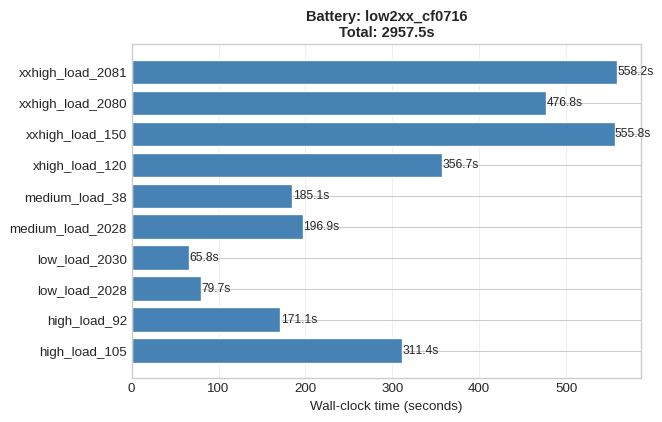


Per-battery totals:
  low2xx_cf0716: 2957.5s


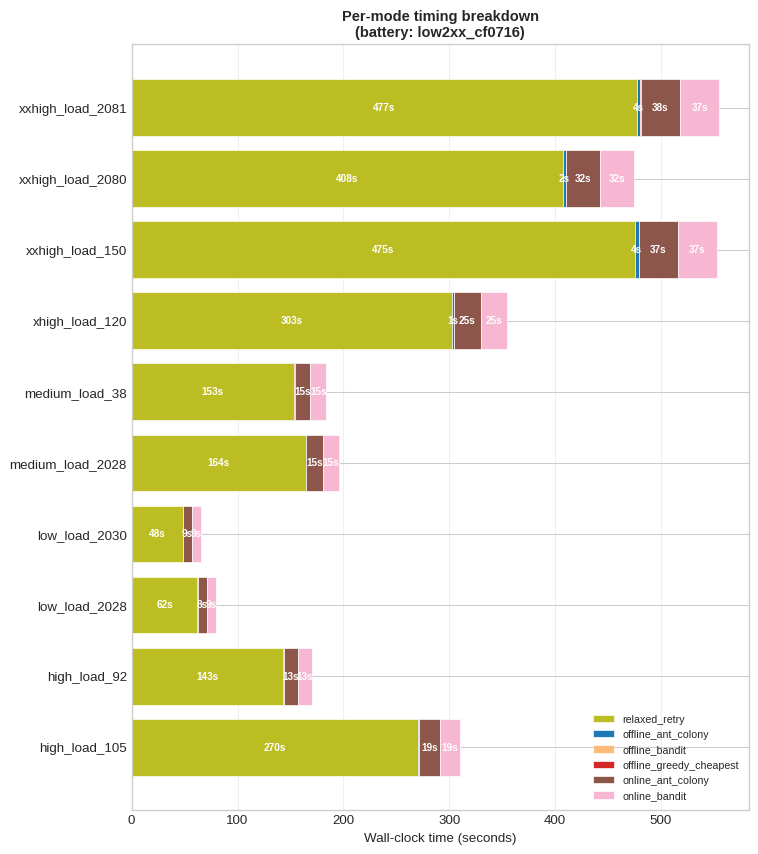

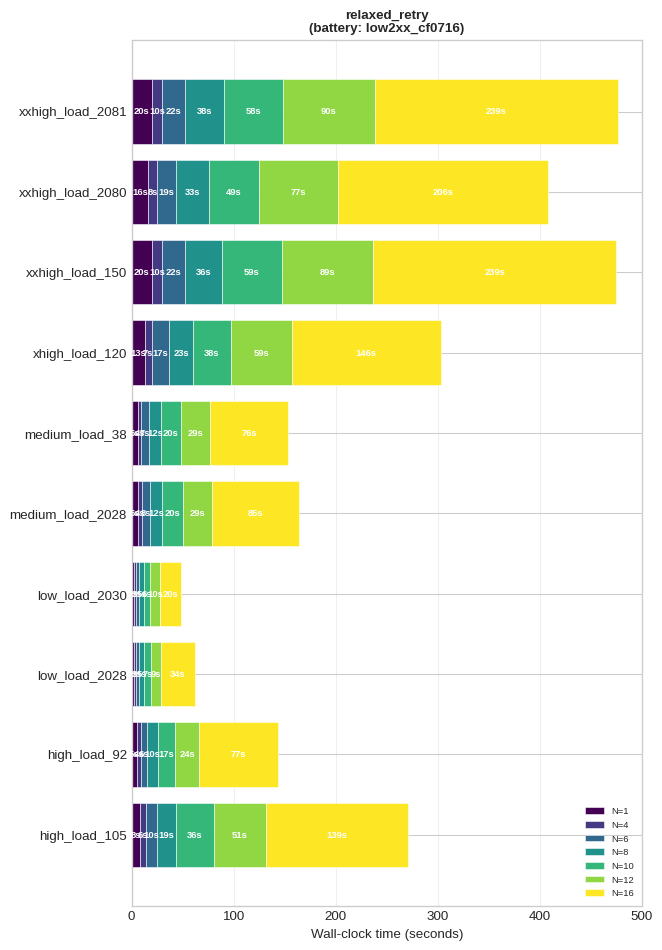


### Strategy execution times (ms)


/tmp/ipykernel_386475/2206901864.py:167: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mean_val = float(row["mean"])
/tmp/ipykernel_386475/2206901864.py:168: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  min_val  = float(row["min"])
/tmp/ipykernel_386475/2206901864.py:169: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  max_val  = float(row["max"])


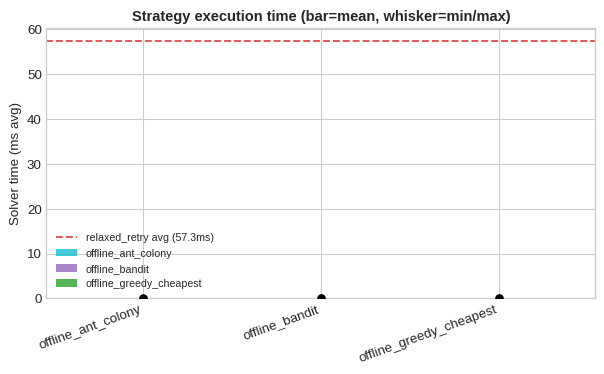

,strategy,min,mean,max
0,offline_ant_colony,0.0000,0.0000,0.0000
1,offline_bandit,0.0000,0.0000,0.0000
2,offline_greedy_cheapest,0.0000,0.0000,0.0000


In [40]:
timing_frames = []
per_n_frames = []
for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p
    if not p.is_absolute():
        p = (_nb_dir / p).resolve()
    stem = p.stem
    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"
    timing_path = p.parent / f"battery_timings{('_' + bid) if bid != 'unnamed' else ''}.csv"
    per_n_path  = p.parent / f"per_n_timings{('_' + bid) if bid != 'unnamed' else ''}.csv"
    if not timing_path.exists():
        print(f"WARNING: timing file not found: {timing_path}")
        continue
    _t = pd.read_csv(timing_path)
    _t.insert(0, "battery_id", bid)
    timing_frames.append(_t)
    if per_n_path.exists():
        _pn = pd.read_csv(per_n_path)
        _pn.insert(0, "battery_id", bid)
        per_n_frames.append(_pn)

if not timing_frames:
    print("No timing files found – run the battery first to generate timings.")
else:
    tdf = pd.concat(timing_frames, ignore_index=True)
    scenario_times = tdf[tdf["scenario_id"] != "__battery_total__"].copy()
    battery_totals = tdf[tdf["scenario_id"] == "__battery_total__"].copy()
    battery_ids = scenario_times["battery_id"].unique().tolist()
    n_batteries = len(battery_ids)

    # ── Chart 1: total wall-clock per scenario ────────────────────────────────
    fig, axes = plt.subplots(1, n_batteries, figsize=(max(7, 5 * n_batteries), 4.5), squeeze=False)
    for ax, bid in zip(axes[0], battery_ids):
        sub = scenario_times[scenario_times["battery_id"] == bid].sort_values("scenario_id")
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        total_s = float(total_row["elapsed_seconds"].iloc[0]) if not total_row.empty else sub["elapsed_seconds"].sum()
        bars = ax.barh(sub["scenario_id"], sub["elapsed_seconds"], color="steelblue", edgecolor="white")
        for bar, val in zip(bars, sub["elapsed_seconds"]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}s", va="center", fontsize=9)
        ax.set_xlabel("Wall-clock time (seconds)")
        ax.set_title(f"Battery: {bid}\nTotal: {total_s:.1f}s", fontsize=11, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("\nPer-battery totals:")
    for bid in battery_ids:
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        if not total_row.empty:
            print(f"  {bid}: {float(total_row['elapsed_seconds'].iloc[0]):.1f}s")

# ── Chart 2: per-N/strategy stacked breakdown ─────────────────────────────────
if per_n_frames:
    pndf = pd.concat(per_n_frames, ignore_index=True)
    battery_ids_pn = pndf["battery_id"].unique().tolist()

    # Build a color map: N values get a sequential palette, strategies get distinct colors
    all_modes = sorted(pndf["mode"].unique().tolist())
    all_ns    = sorted(pndf["batch_size"].unique().tolist())

    # Assign colors: use tab20 for many items
    cmap_n = plt.get_cmap("tab20")
    mode_color = {}
    for i, m in enumerate(all_modes):
        mode_color[m] = cmap_n(i / max(len(all_modes), 1))

    fig, axes = plt.subplots(1, len(battery_ids_pn),
                              figsize=(max(8, 6 * len(battery_ids_pn)), max(3, len(pndf["scenario_id"].unique()) * 0.7 + 2)),
                              squeeze=False)
    for ax, bid in zip(axes[0], battery_ids_pn):
        sub = pndf[pndf["battery_id"] == bid].copy()
        scenarios = sorted(sub["scenario_id"].unique().tolist())
        lefts = {s: 0.0 for s in scenarios}

        # Sort modes so N values come first (numerically), then strategies
        dp_modes  = sorted([m for m in sub["mode"].unique() if m in ("greedy_fallback", "relaxed_retry")])
        strat_modes = sorted([m for m in sub["mode"].unique() if m not in dp_modes])
        ordered_modes = dp_modes + strat_modes

        for mode in ordered_modes:
            vals = []
            for s in scenarios:
                row = sub[(sub["scenario_id"] == s) & (sub["mode"] == mode)]
                if row.empty:
                    vals.append(0.0)
                else:
                    # Sum all batch sizes for this mode (stacked within mode)
                    vals.append(float(row["elapsed_seconds"].sum()))

            color = mode_color.get(mode, "gray")
            bars = ax.barh(scenarios, vals,
                           left=[lefts[s] for s in scenarios],
                           color=color, label=mode, edgecolor="white", linewidth=0.5)
            for s, val in zip(scenarios, vals):
                if val > 1.0:
                    x = lefts[s] + val / 2
                    ax.text(x, scenarios.index(s), f"{val:.0f}s",
                            ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
            for s, val in zip(scenarios, vals):
                lefts[s] += val

        ax.set_xlabel("Wall-clock time (seconds)")
        ax.set_title(f"Per-mode timing breakdown\n(battery: {bid})", fontsize=11, fontweight="bold")
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Chart 3: per-N breakdown per mode (N values stacked) ─────────────────
    for bid in battery_ids_pn:
        sub = pndf[pndf["battery_id"] == bid].copy()
        dp_sub = sub[sub["mode"].isin(["greedy_fallback", "relaxed_retry"])]
        if dp_sub.empty:
            continue
        modes_present = sorted(dp_sub["mode"].unique().tolist())
        scenarios = sorted(dp_sub["scenario_id"].unique().tolist())

        fig, axes2 = plt.subplots(1, len(modes_present),
                                   figsize=(max(7, 5 * len(modes_present)), max(3, len(scenarios) * 0.8 + 2)),
                                   squeeze=False)
        for ax, mode in zip(axes2[0], modes_present):
            msub = dp_sub[dp_sub["mode"] == mode].copy()
            ns_present = sorted(msub["batch_size"].unique().tolist())
            n_colors = plt.get_cmap("viridis")(
                [i / max(len(ns_present) - 1, 1) for i in range(len(ns_present))]
            )
            lefts2 = {s: 0.0 for s in scenarios}
            for ni, (n, col) in enumerate(zip(ns_present, n_colors)):
                vals2 = []
                for s in scenarios:
                    row = msub[(msub["scenario_id"] == s) & (msub["batch_size"] == n)]
                    vals2.append(float(row["elapsed_seconds"].iloc[0]) if not row.empty else 0.0)
                ax.barh(scenarios, vals2, left=[lefts2[s] for s in scenarios],
                        color=col, label=f"N={n}", edgecolor="white", linewidth=0.4)
                for s, val in zip(scenarios, vals2):
                    if val > 2.0:
                        x = lefts2[s] + val / 2
                        ax.text(x, scenarios.index(s), f"{val:.0f}s",
                                ha="center", va="center", fontsize=7, color="white", fontweight="bold")
                for s, val in zip(scenarios, vals2):
                    lefts2[s] += val
            ax.set_xlabel("Wall-clock time (seconds)")
            ax.set_title(f"{mode}\n(battery: {bid})", fontsize=10, fontweight="bold")
            ax.legend(loc="lower right", fontsize=7)
            ax.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No per-N timing files found – run the battery again to generate per_n_timings_*.csv.")

# ── Strategy execution timing ─────────────────────────────────────────────────
if not df_strat.empty and "solver_time_ms_avg" in df_strat.columns:
    print("\n### Strategy execution times (ms)")
    timing_strat = (
        df_strat
        .groupby("infeasibility_mode")["solver_time_ms_avg"]
        .agg(min="min", mean="mean", max="max")
        .reset_index()
        .rename(columns={"infeasibility_mode": "strategy"})
    )

    fig, ax = plt.subplots(figsize=(max(4, len(STRATEGY_NAMES) * 1.8 + 1), 4))
    for i, strat in enumerate(STRATEGY_NAMES):
        row = timing_strat[timing_strat["strategy"] == strat]
        if row.empty:
            continue
        mean_val = float(row["mean"])
        min_val  = float(row["min"])
        max_val  = float(row["max"])
        color = STRATEGY_STYLE.get(strat, {}).get("color", _STRATEGY_FALLBACK_COLORS[i % len(_STRATEGY_FALLBACK_COLORS)])
        ax.bar(i, mean_val, color=color, alpha=0.8, label=strat)
        ax.plot([i, i], [min_val, max_val], color="black", linewidth=2.5, zorder=5)
        ax.scatter([i], [mean_val], color="black", s=30, zorder=6)

    # Reference lines: avg solver time for each mode
    if not df_modes.empty:
        mode_colors = {"greedy_fallback": "tab:orange", "relaxed_retry": "tab:red"}
        for mode, grp in df_modes.groupby("infeasibility_mode"):
            avg = grp["solver_time_ms_avg"].mean()
            ax.axhline(avg, linestyle="--", linewidth=1.4, alpha=0.8,
                       color=mode_colors.get(mode, "gray"),
                       label=f"{mode} avg ({avg:.1f}ms)")

    ax.set_xticks(range(len(STRATEGY_NAMES)))
    ax.set_xticklabels(STRATEGY_NAMES, rotation=20, ha="right")
    ax.set_ylabel("Solver time (ms avg)")
    ax.set_title("Strategy execution time (bar=mean, whisker=min/max)", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    display(timing_strat.round(3))
else:
    print("No strategy data loaded – run battery with additional_strategies to see timings.")


In [41]:
def _series_label(backend: str, mode: str) -> str:
    mode_short = "greedy" if mode == "greedy_fallback" else "relaxed"
    return f"{backend}/{mode_short}"

def _series_style(backend: str, mode: str) -> dict:
    color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
    style = MODE_STYLE.get(mode, {})
    return {"color": color, **style}

def _strategy_style(name: str) -> dict:
    if name in STRATEGY_STYLE:
        return STRATEGY_STYLE[name]
    i = STRATEGY_NAMES.index(name) % len(_STRATEGY_FALLBACK_COLORS)
    return {"color": _STRATEGY_FALLBACK_COLORS[i], "marker": "X"}

def _online_strategy_style(name: str) -> dict:
    if name in ONLINE_STRATEGY_STYLE:
        return ONLINE_STRATEGY_STYLE[name]
    i = ONLINE_STRATEGY_NAMES.index(name) % len(_STRATEGY_FALLBACK_COLORS)
    return {"color": _STRATEGY_FALLBACK_COLORS[i], "linestyle": "--", "marker": "^"}

def _apply_xaxis(ax, rotate=30):
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=rotate, ha="right", fontsize=8)
    if STRATEGY_NAMES and n_bs > 0:
        ax.axvline(x=n_bs - 0.5, linestyle=":", linewidth=0.9, alpha=0.6, color="gray")
        ax.text(n_bs - 0.55, ax.get_ylim()[1], "\u2190 DP / Online",
                ha="right", va="top", fontsize=6, color="gray", style="italic")
        ax.text(n_bs - 0.45, ax.get_ylim()[1], "Offline \u2192",
                ha="left",  va="top", fontsize=6, color="gray", style="italic")


## Metric comparison across scenarios

One figure per metric; each panel is a `(backend, infeasibility_mode)` combo (or online strategy), with one line per scenario and offline-strategy scatter points on the right.

/tmp/ipykernel_386475/2896526984.py:75: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


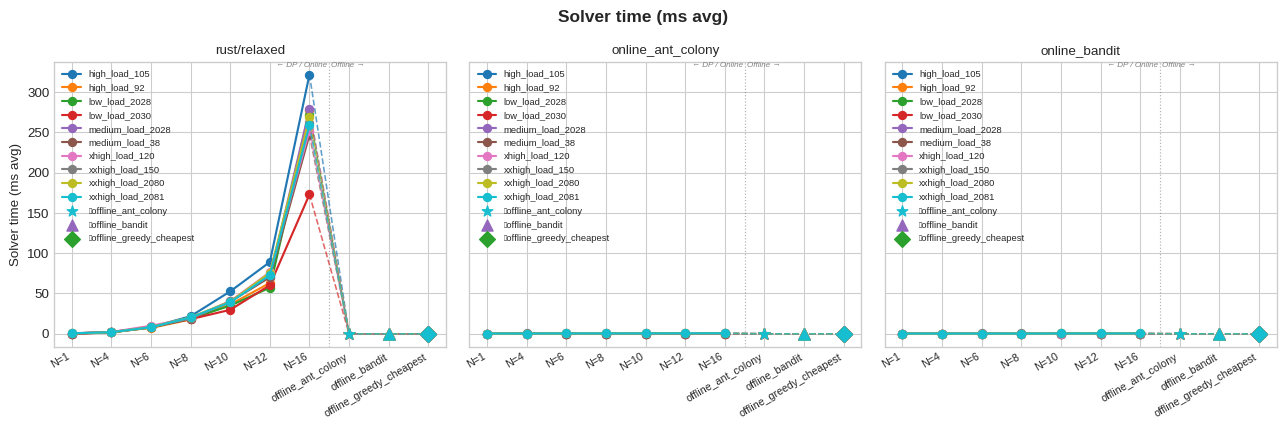

/tmp/ipykernel_386475/2896526984.py:75: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


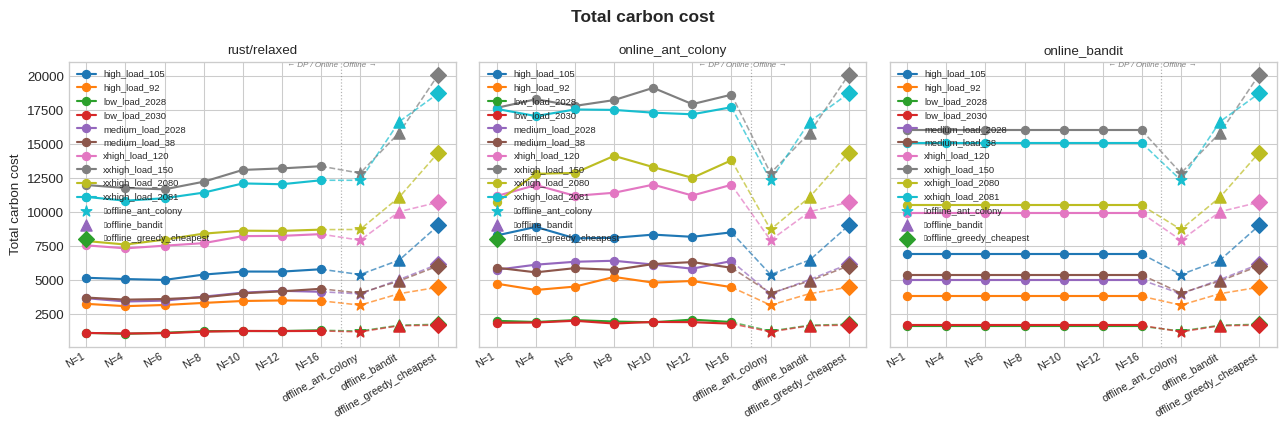

/tmp/ipykernel_386475/2896526984.py:75: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


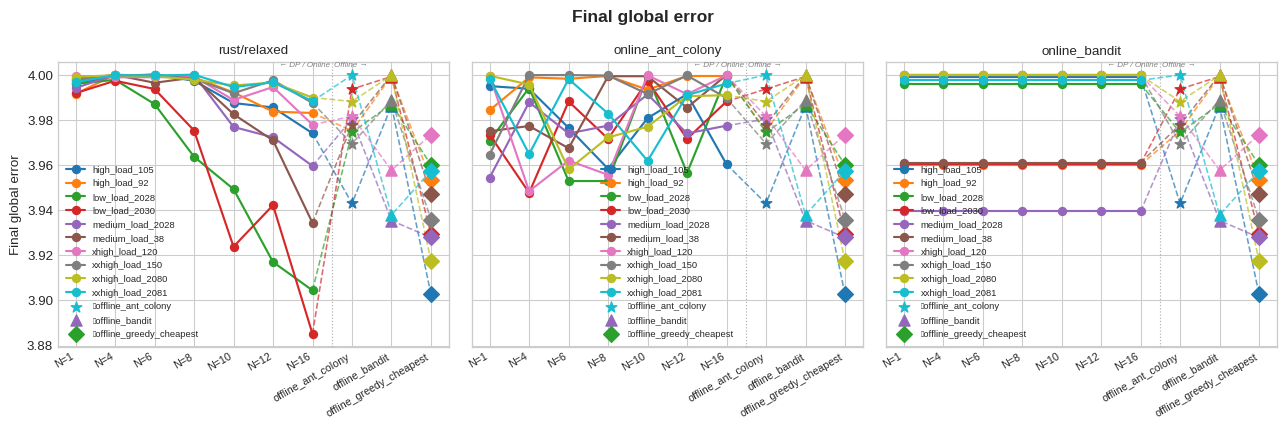

/tmp/ipykernel_386475/2896526984.py:75: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


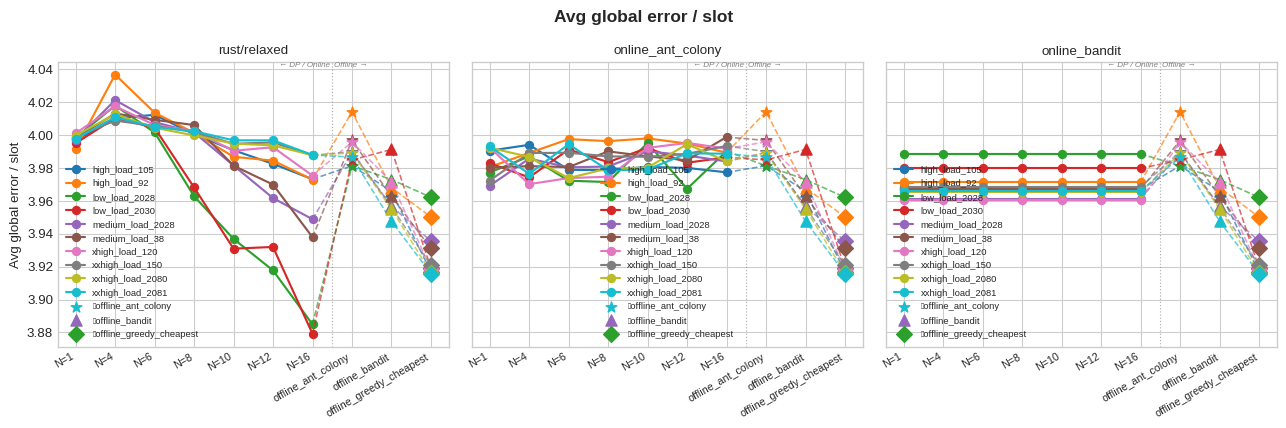

/tmp/ipykernel_386475/2896526984.py:75: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


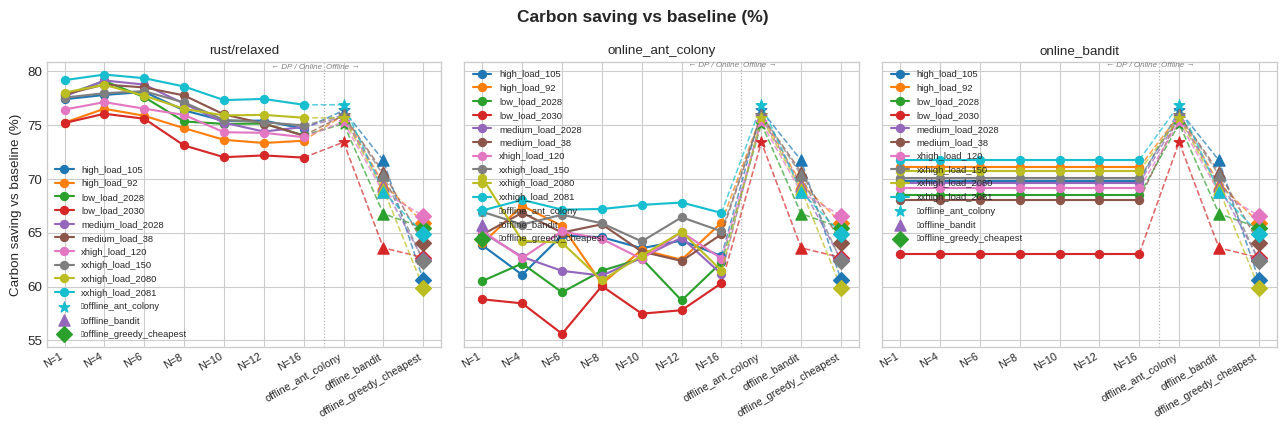

/tmp/ipykernel_386475/2896526984.py:75: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


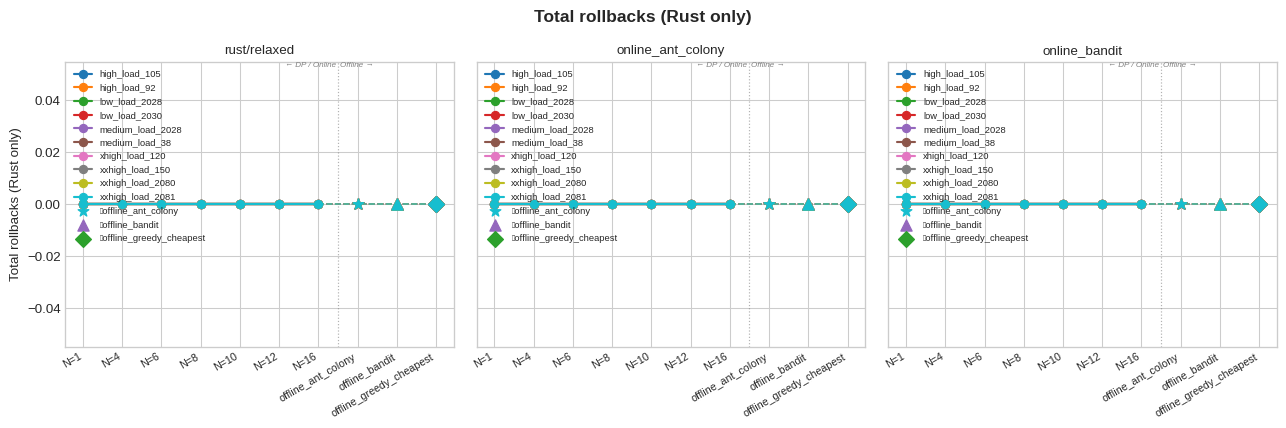

/tmp/ipykernel_386475/2896526984.py:75: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


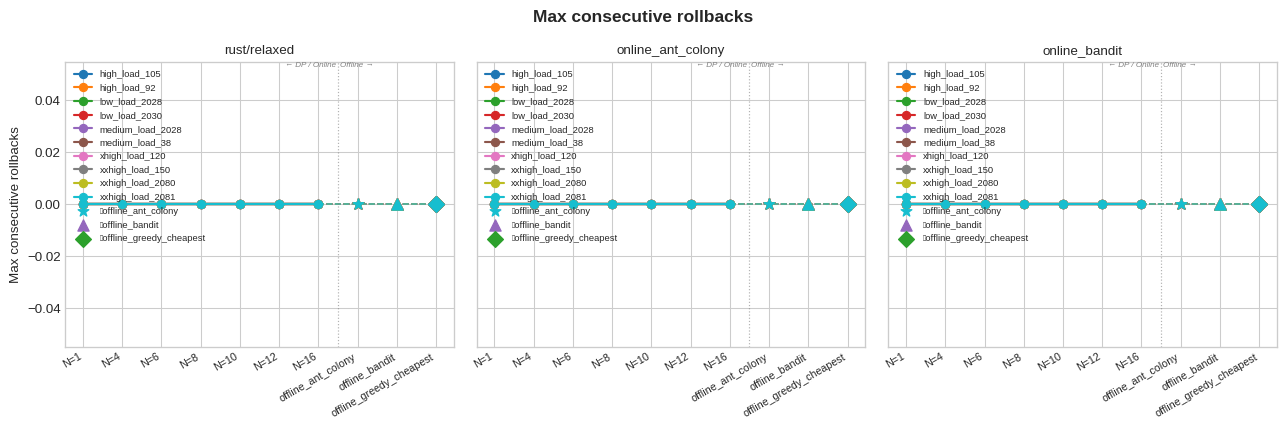

/tmp/ipykernel_386475/2896526984.py:75: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


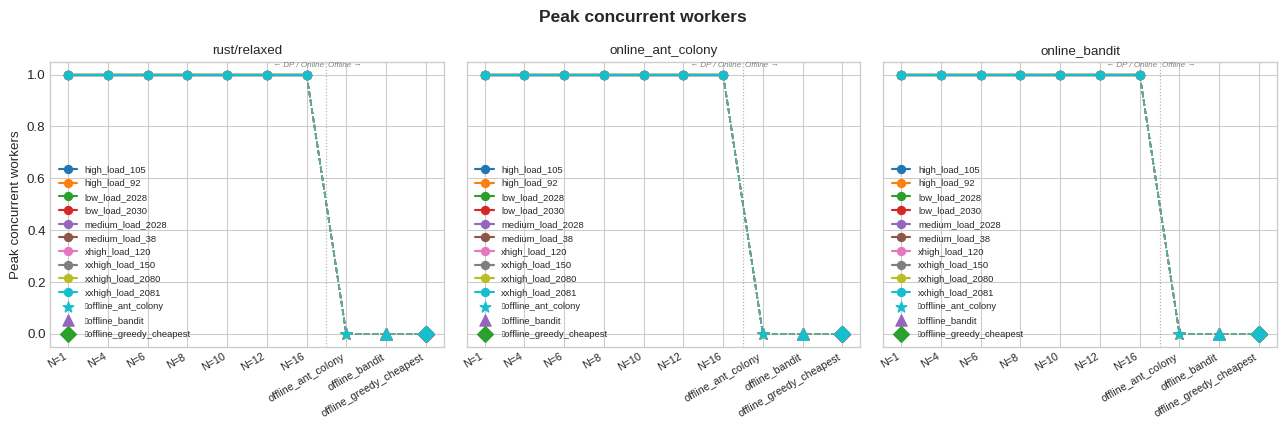

/tmp/ipykernel_386475/2896526984.py:75: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


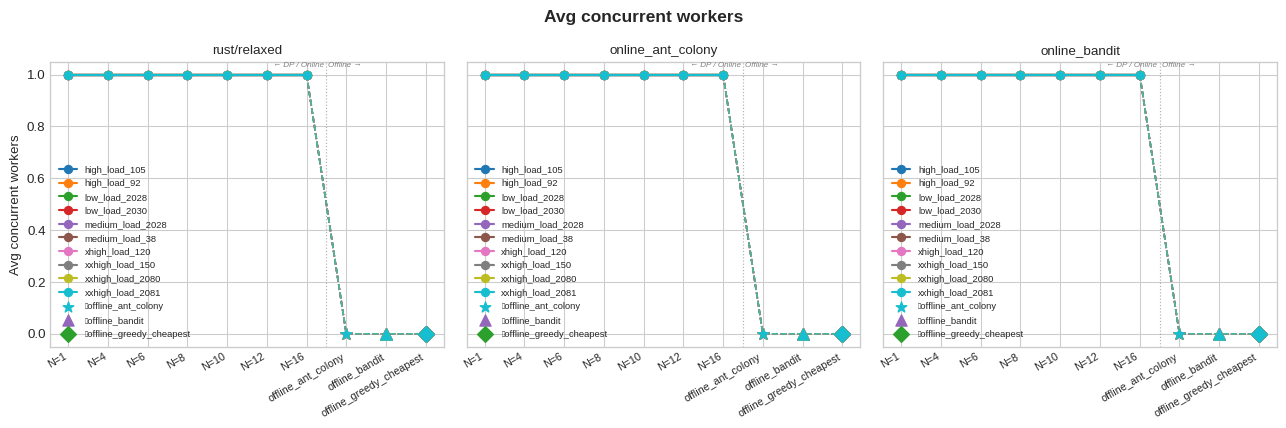

In [42]:
# Build panels: one per DP combo, then one per online strategy
_panels_8 = list(combos) + [("rust", ostrat) for ostrat in ONLINE_STRATEGY_NAMES]

_n_panels = max(len(_panels_8), 1)
_fig_w = max(6, 4.5 * _n_panels)

colors_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
sid_color = {sid: colors_cycle[i % len(colors_cycle)] for i, sid in enumerate(scenarios)}

for m in METRICS:
    fig, axes = plt.subplots(1, _n_panels, figsize=(_fig_w, 4.5), sharey=True)
    if _n_panels == 1:
        axes = [axes]
    fig.suptitle(m["label"], fontsize=13, fontweight="bold")

    for ax, (pbackend, pmode) in zip(axes, _panels_8):
        is_online = pmode.startswith("online_")
        ax.set_title(pmode if is_online else _series_label(pbackend, pmode), fontsize=10)
        if ax is axes[0]:
            ax.set_ylabel(m["label"])

        for sid in scenarios:
            if is_online:
                sub = df_online[
                    (df_online["scenario_id"] == sid) &
                    (df_online["infeasibility_mode"] == pmode)
                ].sort_values("batch_size")
            else:
                sub = df_modes[
                    (df_modes["scenario_id"] == sid) &
                    (df_modes["backend"] == pbackend) &
                    (df_modes["infeasibility_mode"] == pmode)
                ].sort_values("batch_size")
            if sub.empty or m["col"] not in sub.columns:
                continue
            xs = [bs_to_x[bs] for bs in sub["batch_size"] if bs in bs_to_x]
            ys = [float(sub[sub["batch_size"] == bs][m["col"]].values[0])
                  for bs in sub["batch_size"] if bs in bs_to_x]
            if not xs:
                continue
            ax.plot(xs, ys, marker="o", linewidth=1.6, color=sid_color[sid], label=sid)
            # Dashed extension to offline strategy scatter points
            if not df_strat.empty and STRATEGY_NAMES:
                ext_xs, ext_ys = [xs[-1]], [ys[-1]]
                for strat in STRATEGY_NAMES:
                    sub_s = df_strat[
                        (df_strat["scenario_id"] == sid) &
                        (df_strat["infeasibility_mode"] == strat)
                    ]
                    if sub_s.empty or m["col"] not in sub_s.columns:
                        continue
                    ext_xs.append(strat_to_x[strat])
                    ext_ys.append(float(sub_s[m["col"]].values[0]))
                if len(ext_xs) > 1:
                    ax.plot(ext_xs, ext_ys, linestyle="--", linewidth=1.2,
                            alpha=0.7, color=sid_color[sid])

        # Offline strategy scatter (one marker per strategy, colour by scenario)
        for strat in STRATEGY_NAMES:
            sty = _strategy_style(strat)
            for sid in scenarios:
                sub_s = df_strat[
                    (df_strat["scenario_id"] == sid) &
                    (df_strat["infeasibility_mode"] == strat)
                ]
                if sub_s.empty or m["col"] not in sub_s.columns:
                    continue
                ax.scatter([strat_to_x[strat]], [float(sub_s[m["col"]].values[0])],
                           s=70, zorder=5, color=sid_color[sid], marker=sty["marker"])
            ax.scatter([], [], s=70, marker=sty["marker"], color=sty["color"], label=f"\u25b8{strat}")

        _apply_xaxis(ax)
        ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()


## Aggregate statistics

Min / mean / max of each metric across all loaded scenarios, grouped by `(backend, infeasibility_mode, batch_size)`.

In [43]:
metric_cols = [m["col"] for m in METRICS]
agg_modes = (
    df_modes.groupby(["backend", "infeasibility_mode", "batch_size"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
print("=== Modes: min / mean / max per (backend, mode, batch_size) ===")
display(agg_modes)

if not df_strat.empty:
    agg_strat = (
        df_strat.groupby(["infeasibility_mode"])[metric_cols]
        .agg(["min", "mean", "max"])
        .round(4)
    )
    print("\n=== Offline strategies: min / mean / max across all scenarios ===")
    display(agg_strat)

if not df_online.empty:
    agg_online = (
        df_online.groupby(["infeasibility_mode", "batch_size"])[metric_cols]
        .agg(["min", "mean", "max"])
        .round(4)
    )
    print("\n=== Online Strategies: min / mean / max per (strategy, N) ===")
    display(agg_online)


=== Modes: min / mean / max per (backend, mode, batch_size) ===


solver_time_ms_avg                    \
                                                     min     mean      max   
backend infeasibility_mode batch_size                                        
rust    relaxed_retry      1                      0.0807   0.3696   0.6497   
                           4                      1.6333   2.0025   2.3509   
                           6                      7.2501   8.3495  10.0383   
                           8                     17.8303  19.3956  21.8209   
                           10                    29.7560  39.2952  52.6203   
                           12                    57.3031  70.8179  89.0227   
                           16                   172.8825 260.9242 321.6067   

                                      total_carbon_cost                       \
                                                    min      mean        max   
backend infeasibility_mode batch_size                                          
rust    relaxed_retry      1                  1133.2830 5672.6685 11999.7168   
                           4                  1070.2268 5498.8258 11782.4028   
                           6                  1115.1761 5585.3161 11683.9510   
                           8                  1228.5625 5864.5300 12242.3584   
                           10                 1274.1429 6193.3375 13109.3472   
                           12                 1270.7824 6229.0660 13221.9269   
                           16                 1279.9717 6329.8288 13382.5222   

                                      final_global_error                \
                                                     min   mean    max   
backend infeasibility_mode batch_size                                    
rust    relaxed_retry      1                      3.9916 3.9962 3.9995   
                           4                      3.9974 3.9993 4.0001   
                           6                      3.9871 3.9975 4.0002   
                           8                      3.9637 3.9930 4.0001   
                           10                     3.9238 3.9783 3.9953   
                           12                     3.9170 3.9757 3.9976   
                           16                     3.8852 3.9585 3.9899   

                                      avg_global_error_per_slot                \
                                                            min   mean    max   
backend infeasibility_mode batch_size                                           
rust    relaxed_retry      1                             3.9915 3.9974 4.0011   
                           4                             4.0089 4.0160 4.0368   
                           6                             4.0017 4.0070 4.0136   
                           8                             3.9629 3.9947 4.0061   
                           10                            3.9309 3.9785 3.9968   
                           12                            3.9177 3.9727 3.9968   
                           16                            3.8791 3.9536 3.9879   

                                      carbon_cost_saving_vs_baseline_pct  \
                                                                     min   
backend infeasibility_mode batch_size                                      
rust    relaxed_retry      1                                     75.1906   
                           4                                     76.0503   
                           6                                     75.5870   
                           8                                     73.1048   
                           10                                    72.0183   
                           12                                    72.1805   
                           16                                    71.9793   

                                                      total_rollbacks         \
                                         mean     max          


=== Offline strategies: min / mean / max across all scenarios ===


solver_time_ms_avg               total_carbon_cost  \
                                       min   mean    max               min   
infeasibility_mode                                                           
offline_ant_colony                  0.0000 0.0000 0.0000         1214.5203   
offline_bandit                      0.0000 0.0000 0.0000         1663.0570   
offline_greedy_cheapest             0.0000 0.0000 0.0000         1703.9452   

                                             final_global_error                \
                             mean        max                min   mean    max   
infeasibility_mode                                                              
offline_ant_colony      6104.4413 12868.0166             3.9430 3.9784 3.9999   
offline_bandit          7753.9857 16660.9127             3.9354 3.9792 4.0000   
offline_greedy_cheapest 9323.2177 20114.8830             3.9028 3.9405 3.9736   

                        avg_global_error_per_slot                \
                                              min   mean    max   
infeasibility_mode                                                
offline_ant_colony                         3.9813 3.9909 4.0141   
offline_bandit                             3.9476 3.9648 3.9913   
offline_greedy_cheapest                    3.9158 3.9286 3.9621   

                        carbon_cost_saving_vs_baseline_pct                  \
                                                       min    mean     max   
infeasibility_mode                                                           
offline_ant_colony                                 73.4122 75.6221 76.8867   
offline_bandit                                     63.5930 68.8559 71.7132   
offline_greedy_cheapest                            59.8999 63.4999 66.5870   

                        total_rollbacks            max_consecutive_rollbacks  \
                                    min   mean max                       min   
infeasibility_mode                                                             
offline_ant_colony                    0 0.0000   0                         0   
offline_bandit                        0 0.0000   0                         0   
offline_greedy_cheapest               0 0.0000   0                         0   

                                   peak_concurrent_workers             \
                          mean max                     min   mean max   
infeasibility_mode                                                      
offline_ant_colony      0.0000   0                       0 0.0000   0   
offline_bandit          0.0000   0                       0 0.0000   0   
offline_greedy_cheapest 0.0000   0                       0 0.0000   0   

                        avg_concurrent_workers                
                                           min   mean    max  
infeasibility_mode                                            
offline_ant_colony                      0.0000 0.0000 0.0000  
offline_bandit                          0.0000 0.0000 0.0000  
offline_greedy_cheapest                 0.0000 0.0000 0.0000


=== Online Strategies: min / mean / max per (strategy, N) ===


solver_time_ms_avg                \
                                             min   mean    max   
infeasibility_mode batch_size                                    
online_ant_colony  1                      0.0508 0.2024 0.3558   
                   4                      0.0642 0.2389 0.4482   
                   6                      0.0854 0.2747 0.4790   
                   8                      0.0828 0.3007 0.5175   
                   10                     0.0956 0.3369 0.5454   
                   12                     0.0974 0.3561 0.6229   
                   16                     0.1143 0.3905 0.7270   
online_bandit      1                      0.0455 0.1760 0.3440   
                   4                      0.0625 0.2011 0.3640   
                   6                      0.0581 0.2146 0.3902   
                   8                      0.0619 0.2183 0.3820   
                   10                     0.0608 0.2206 0.4310   
                   12                     0.0569 0.2229 0.4396   
                   16                     0.0648 0.2396 0.4398   

                              total_carbon_cost                       \
                                            min      mean        max   
infeasibility_mode batch_size                                          
online_ant_colony  1                  1881.1321 8583.0732 17669.3239   
                   4                  1898.2594 8896.7200 18299.8978   
                   6                  2027.3820 8843.9694 17813.3139   
                   8                  1824.7801 9069.8759 18239.4374   
                   10                 1914.5040 9119.1925 19139.2687   
                   12                 1927.3544 8827.0727 17942.0792   
                   16                 1812.6017 9128.3915 18636.3237   
online_bandit      1                  1613.4313 7595.8598 16008.7486   
                   4                  1613.4313 7595.8598 16008.7486   
                   6                  1613.4313 7595.8598 16008.7486   
                   8                  1613.4313 7595.8598 16008.7486   
                   10                 1613.4313 7595.8598 16008.7486   
                   12                 1613.4313 7595.8598 16008.7486   
                   16                 1613.4313 7595.8598 16008.7486   

                              final_global_error                \
                                             min   mean    max   
infeasibility_mode batch_size                                    
online_ant_colony  1                      3.9544 3.9815 3.9996   
                   4                      3.9478 3.9809 3.9999   
                   6                      3.9529 3.9776 3.9999   
                   8                      3.9529 3.9770 3.9997   
                   10                     3.9619 3.9892 3.9998   
                   12                     3.9565 3.9852 3.9997   
                   16                     3.9603 3.9902 4.0000   
online_bandit      1                      3.9394 3.9813 3.9999   
                   4                      3.9394 3.9813 3.9999   
                   6                      3.9394 3.9813 3.9999   
                   8                      3.9394 3.9813 3.9999   
                   10                     3.9394 3.9813 3.9999   
                   12                     3.9394 3.9813 3.9999   
                   16                     3.9394 3.9813 3.9999   

                              avg_global_error_per_slot                \
                                                    min   mean    max   
infeasibility_mode batch_size                                           
online_ant_colony  1                             3.9692 3.9831 3.9931   
                   4                             3.9701 3.9834 3.9941   
                   6                             3.9722 3.9832 3.9975   
                   8                             3.9714 3.9821 3.9963   
                   10                           

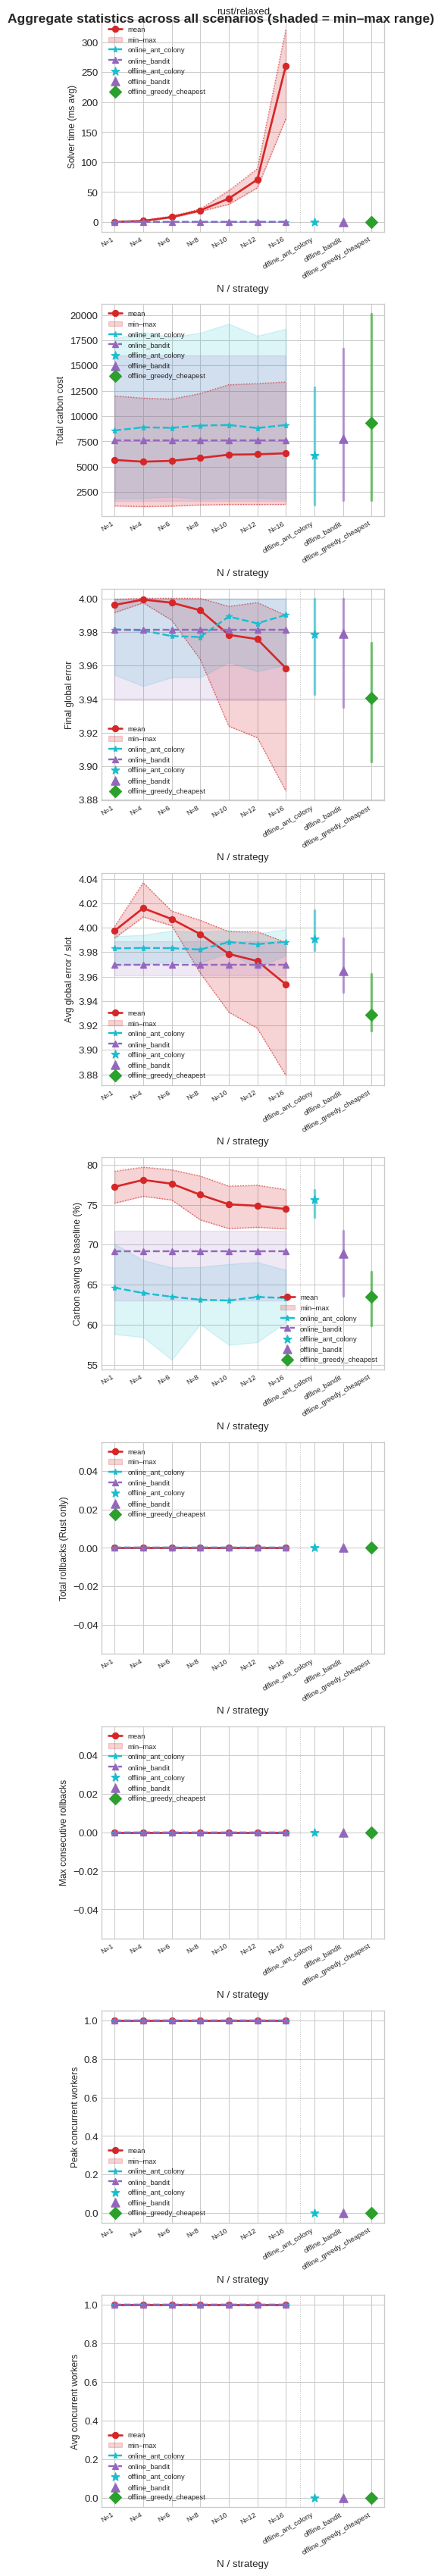

In [44]:
combos_sorted = sorted(combos)
fig_rows = len(METRICS)
fig_cols = max(len(combos_sorted), 1)

fig, axes = plt.subplots(
    fig_rows, fig_cols,
    figsize=(4.8 * fig_cols, 4.0 * fig_rows),
    squeeze=False,
    sharey="row",
)
fig.suptitle("Aggregate statistics across all scenarios (shaded = min–max range)\n",
             fontsize=13, fontweight="bold")

for row, m in enumerate(METRICS):
    for col, (backend, mode) in enumerate(combos_sorted):
        ax = axes[row][col]
        sub = df_modes[(df_modes["backend"] == backend) & (df_modes["infeasibility_mode"] == mode)]
        if sub.empty:
            ax.set_visible(False)
            continue
        grp = (
            sub.groupby("batch_size")[m["col"]]
            .agg(["min", "mean", "max"])
            .reset_index()
            .sort_values("batch_size")
        )
        xs = [bs_to_x[bs] for bs in grp["batch_size"]]
        color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
        ax.plot(xs, grp["mean"], marker="o", linewidth=2.0, color=color, label="mean")
        ax.fill_between(xs, grp["min"], grp["max"], alpha=0.2, color=color, label="min–max")
        ax.plot(xs, grp["min"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)
        ax.plot(xs, grp["max"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)

        # Online strategy lines: mean ± fill across scenarios per N
        for ostrat in ONLINE_STRATEGY_NAMES:
            if df_online.empty:
                continue
            sub_o = df_online[df_online["infeasibility_mode"] == ostrat]
            if sub_o.empty or m["col"] not in sub_o.columns:
                continue
            grp_o = (
                sub_o.groupby("batch_size")[m["col"]]
                .agg(["min", "mean", "max"])
                .reset_index().sort_values("batch_size")
            )
            xs_o = [bs_to_x[bs] for bs in grp_o["batch_size"] if bs in bs_to_x]
            sty_o = _online_strategy_style(ostrat)
            means_o = [float(grp_o[grp_o["batch_size"] == bs]["mean"].values[0])
                       for bs in grp_o["batch_size"] if bs in bs_to_x]
            mins_o  = [float(grp_o[grp_o["batch_size"] == bs]["min"].values[0])
                       for bs in grp_o["batch_size"] if bs in bs_to_x]
            maxs_o  = [float(grp_o[grp_o["batch_size"] == bs]["max"].values[0])
                       for bs in grp_o["batch_size"] if bs in bs_to_x]
            if xs_o:
                ax.plot(xs_o, means_o, linewidth=1.8, label=ostrat, **sty_o)
                ax.fill_between(xs_o, mins_o, maxs_o, alpha=0.15, color=sty_o["color"])

        # Strategy points: mean ± range across scenarios
        for strat in STRATEGY_NAMES:
            if df_strat.empty:
                continue
            vals = df_strat[df_strat["infeasibility_mode"] == strat][m["col"]].dropna()
            if vals.empty:
                continue
            x_pos = strat_to_x[strat]
            sty = _strategy_style(strat)
            sc = ax.scatter([x_pos], [vals.mean()], s=70, zorder=5,
                            color=sty["color"], marker=sty["marker"], label=strat)
            ax.plot([x_pos, x_pos], [vals.min(), vals.max()],
                    color=sty["color"], linewidth=2.5, alpha=0.6)

        if STRATEGY_NAMES and n_bs > 0:
            ax.axvline(x=n_bs - 0.5, linestyle=":", linewidth=0.8, alpha=0.5, color="gray")
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=7)
        ax.set_xlabel("N / strategy")
        if row == 0:
            ax.set_title(_series_label(backend, mode), fontsize=10)
        if col == 0:
            ax.set_ylabel(m["label"], fontsize=9)
        ax.legend(fontsize=7, loc="best")

plt.tight_layout()
plt.show()


In [45]:
metric_cols = [m["col"] for m in METRICS]

overall_modes = (
    df_modes.groupby(["backend", "infeasibility_mode"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
print("Overall min / mean / max across ALL scenarios and ALL N values (modes):")
display(overall_modes)

if not df_strat.empty:
    overall_strat = (
        df_strat.groupby("infeasibility_mode")[metric_cols]
        .agg(["min", "mean", "max"])
        .round(4)
    )
    print("\nOverall min / mean / max across ALL scenarios (strategies):")
    display(overall_strat)


Overall min / mean / max across ALL scenarios and ALL N values (modes):


solver_time_ms_avg                   \
                                          min    mean      max   
backend infeasibility_mode                                       
rust    relaxed_retry                  0.0807 57.3078 321.6067   

                           total_carbon_cost                       \
                                         min      mean        max   
backend infeasibility_mode                                          
rust    relaxed_retry              1070.2268 5910.5104 13382.5222   

                           final_global_error                \
                                          min   mean    max   
backend infeasibility_mode                                    
rust    relaxed_retry                  3.8852 3.9855 4.0002   

                           avg_global_error_per_slot                \
                                                 min   mean    max   
backend infeasibility_mode                                           
rust    relaxed_retry                         3.8791 3.9886 4.0368   

                           carbon_cost_saving_vs_baseline_pct                  \
                                                          min    mean     max   
backend infeasibility_mode                                                      
rust    relaxed_retry                                 71.9793 76.2147 79.6897   

                           total_rollbacks             \
                                       min   mean max   
backend infeasibility_mode                              
rust    relaxed_retry                    0 0.0000   0   

                           max_consecutive_rollbacks             \
                                                 min   mean max   
backend infeasibility_mode                                        
rust    relaxed_retry                              0 0.0000   0   

                           peak_concurrent_workers             \
                                               min   mean max   
backend infeasibility_mode                                      
rust    relaxed_retry                            1 1.0000   1   

                           avg_concurrent_workers                
                                              min   mean    max  
backend infeasibility_mode                                       
rust    relaxed_retry                      1.0000 1.0000 1.0000


Overall min / mean / max across ALL scenarios (strategies):


solver_time_ms_avg               total_carbon_cost  \
                                       min   mean    max               min   
infeasibility_mode                                                           
offline_ant_colony                  0.0000 0.0000 0.0000         1214.5203   
offline_bandit                      0.0000 0.0000 0.0000         1663.0570   
offline_greedy_cheapest             0.0000 0.0000 0.0000         1703.9452   

                                             final_global_error                \
                             mean        max                min   mean    max   
infeasibility_mode                                                              
offline_ant_colony      6104.4413 12868.0166             3.9430 3.9784 3.9999   
offline_bandit          7753.9857 16660.9127             3.9354 3.9792 4.0000   
offline_greedy_cheapest 9323.2177 20114.8830             3.9028 3.9405 3.9736   

                        avg_global_error_per_slot                \
                                              min   mean    max   
infeasibility_mode                                                
offline_ant_colony                         3.9813 3.9909 4.0141   
offline_bandit                             3.9476 3.9648 3.9913   
offline_greedy_cheapest                    3.9158 3.9286 3.9621   

                        carbon_cost_saving_vs_baseline_pct                  \
                                                       min    mean     max   
infeasibility_mode                                                           
offline_ant_colony                                 73.4122 75.6221 76.8867   
offline_bandit                                     63.5930 68.8559 71.7132   
offline_greedy_cheapest                            59.8999 63.4999 66.5870   

                        total_rollbacks            max_consecutive_rollbacks  \
                                    min   mean max                       min   
infeasibility_mode                                                             
offline_ant_colony                    0 0.0000   0                         0   
offline_bandit                        0 0.0000   0                         0   
offline_greedy_cheapest               0 0.0000   0                         0   

                                   peak_concurrent_workers             \
                          mean max                     min   mean max   
infeasibility_mode                                                      
offline_ant_colony      0.0000   0                       0 0.0000   0   
offline_bandit          0.0000   0                       0 0.0000   0   
offline_greedy_cheapest 0.0000   0                       0 0.0000   0   

                        avg_concurrent_workers                
                                           min   mean    max  
infeasibility_mode                                            
offline_ant_colony                      0.0000 0.0000 0.0000  
offline_bandit                          0.0000 0.0000 0.0000  
offline_greedy_cheapest                 0.0000 0.0000 0.0000